# Real Data

## Signaling Gene Xmic Enrichment

Using AUC method order: ['MintFlow', 'SIMVI', 'NiCo', 'MEFISTO', 'Random (uniform)', 'Random (binary)']
Saved me_enrichment_processed.csv


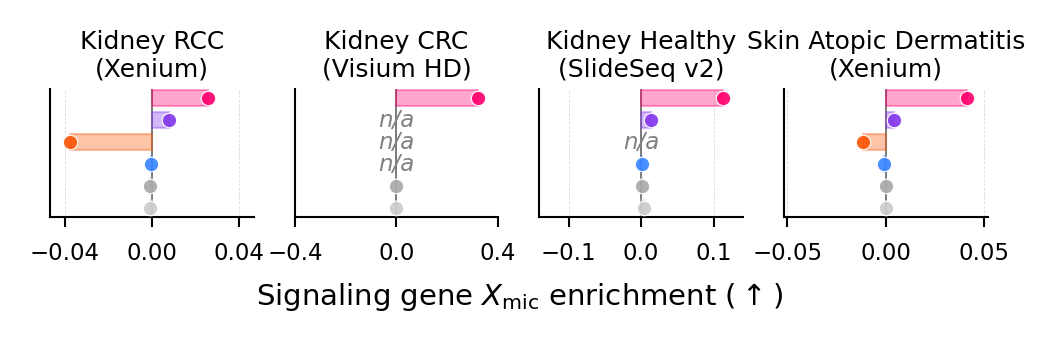

Saved me_enrichment_figure.pdf / .svg / .png


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ── Column mapping & colours ────────────────────────────────────────────
method_rename = {
    "1_MintFlow": "MintFlow",
    "2_SimVI": "SIMVI",
    "3_Mefisto": "MEFISTO",
    "4_NiCo": "NiCo",
    "5_RandomUniform": "Random (uniform)",
    "6_RandomBinary": "Random (binary)",
}

method_colors = {
    "MEFISTO":            "#3A86FF",
    "SIMVI":              "#8338EC",
    "MintFlow":           "#FF006E",
    "NiCo":               "#FB5607",
    "Random (uniform)":   "#AAAAAA",
    "Random (binary)":    "#CCCCCC",
}

# Nicer dataset display names
dataset_rename = {
    "1024HVGs_1_RCC": "Kidney RCC\n(Xenium)",
    "4_CRC_VisiumHD_Publis": "Kidney CRC\n(Visium HD)",
    "SlideSeq_Kidney_puck01": "Kidney Healthy\n(SlideSeq v2)",
    "Z_AD_10sections_MintFlowPreprint": "Skin Atopic Dermatitis\n(Xenium)",
}

OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/disentanglement"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load data ───────────────────────────────────────────────────────────
df_meanminusmean = pd.read_pickle(
    "/nfs/team361/aa36/OnGit/mintflow-benchmarking/Metrics/"
    "1_Disentanglement/3_Actual_Benchmarks/NonGit/ToMakeFigs/"
    "df_realdata_mean_minus_mean.pkl"
)

sub = df_meanminusmean[df_meanminusmean["metric"] == "mean minus mean"].copy()
sub["method"] = sub["method"].map(method_rename)
pivot = sub.pivot(index="dataset", columns="method", values="value")

# Keep signed values (no abs)
# Use same method ordering as AUC plot (read from AUC processed CSV, or fallback)
auc_csv_path = os.path.join(OUT_DIR, "auc_processed.csv")
if os.path.exists(auc_csv_path):
    auc_df = pd.read_csv(auc_csv_path)
    sorted_methods = [m for m in auc_df.columns if m in pivot.columns]
    print(f"Using AUC method order: {sorted_methods}")
else:
    # Fallback: sort by mean descending
    sorted_methods = pivot.mean().sort_values(ascending=False).index.tolist()
    print("AUC CSV not found, using own sorting")
pivot_sorted = pivot[sorted_methods]

dataset_order = {
    "1024HVGs_1_RCC": 0,
    "4_CRC_VisiumHD_Publis": 1,
    "SlideSeq_Kidney_puck01": 2,
    "Z_AD_10sections_MintFlowPreprint": 3,
}
datasets = sorted(pivot_sorted.index.tolist(), key=lambda d: dataset_order.get(d, 99))
methods = sorted_methods
n_methods = len(methods)
n_datasets = len(datasets)

# Save processed CSV
pivot_sorted.to_csv(os.path.join(OUT_DIR, "me_enrichment_processed.csv"))
print("Saved me_enrichment_processed.csv")

# ── Helper: plot one dataset panel ──────────────────────────────────────
def plot_dataset_panel(ax, values, methods, dataset_name, show_ylabels=True):
    """Plot a single dataset panel. values is a Series indexed by method."""
    y = np.arange(len(methods))

    for i, method in enumerate(methods):
        val = values.get(method, np.nan)
        if pd.isna(val):
            # Show "n/a" text centred on the row
            ax.text(
                0.5, i, "n/a",
                va="center", ha="center",
                fontsize=5.5, fontstyle="italic", color="0.5",
                transform=ax.get_yaxis_transform(),
            )
        else:
            # Bar
            ax.barh(
                i, val, height=0.7,
                color=method_colors[method],
                edgecolor=method_colors[method],
                linewidth=0.5, alpha=0.35, zorder=2,
            )
            # Dot
            ax.scatter(
                val, i, s=12, color=method_colors[method],
                edgecolors="white", linewidths=0.3, zorder=4, alpha=0.92,
            )

    ax.set_yticks(y)
    if show_ylabels:
        ax.set_yticklabels(methods, fontweight="medium")
    else:
        ax.set_yticklabels([])

    ax.axvline(0, color="0.4", linewidth=0.4, zorder=1)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-0.4, len(methods) - 0.6)
    ax.invert_yaxis()

    ax.xaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=2, integer=False))

    display_name = dataset_rename.get(dataset_name, dataset_name)
    ax.set_title(display_name, fontsize=6, fontweight="medium", pad=3)


# ── Create 1×N panel figure ─────────────────────────────────────────────
panel_width = 18 * mm
row_height = 0.12
fig_height = n_methods * row_height + 0.35
fig_width = panel_width * n_datasets + 0.65  # extra for y-labels

fig, axes = plt.subplots(
    1, n_datasets,
    figsize=(fig_width, fig_height),
    sharey=True,
)

# Per-panel symmetric x-limits based on each dataset's data range
for i, dataset in enumerate(datasets):
    row = pivot_sorted.loc[dataset]
    plot_dataset_panel(axes[i], row, methods, dataset, show_ylabels=(i == 0))
    panel_absmax = row.abs().max()
    pad = panel_absmax * 0.25 if panel_absmax > 0 else 0.01
    axes[i].set_xlim(-panel_absmax - pad, panel_absmax + pad)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, bottom=0.32)

# Single shared x-axis label
fig.text(
    0.5, 0.07,
    r"Signaling gene $X_{\mathrm{mic}}$ enrichment ($\uparrow$)",
    ha="center", va="center", fontsize=7, fontweight="medium",
)

for ext in ["pdf", "svg", "png"]:
    fig.savefig(
        os.path.join(OUT_DIR, f"me_enrichment_figure.{ext}"),
        bbox_inches="tight",
        pad_inches=0.05,
    )
plt.show()
plt.close()
print("Saved me_enrichment_figure.pdf / .svg / .png")

## AUC

Saved auc_processed.csv


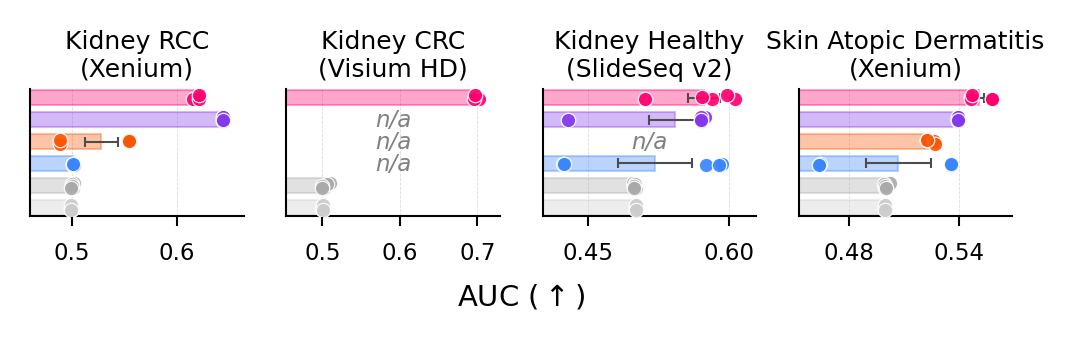

Saved auc_figure.pdf / .svg / .png


In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

method_rename = {
    "1_MintFlow": "MintFlow",
    "2_SimVI": "SIMVI",
    "3_Mefisto": "MEFISTO",
    "4_NiCo": "NiCo",
    "5_RandomUniform": "Random (uniform)",
    "6_RandomBinary": "Random (binary)",
}
method_colors = {
    "MEFISTO":            "#3A86FF",
    "SIMVI":              "#8338EC",
    "MintFlow":           "#FF006E",
    "NiCo":               "#FB5607",
    "Random (uniform)":   "#AAAAAA",
    "Random (binary)":    "#CCCCCC",
}
dataset_rename = {
    "1024HVGs_1_RCC": "Kidney RCC\n(Xenium)",
    "SlideSeq_Kidney_puck01": "Kidney Healthy\n(SlideSeq v2)",
    "4_CRC_VisiumHD_Publis": "Kidney CRC\n(Visium HD)",
    "Z_AD_10sections_MintFlowPreprint": "Skin Atopic Dermatitis\n(Xenium)",
}

OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/disentanglement"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load data ───────────────────────────────────────────────────────────
# UPDATE THIS PATH to your AUC CSV location
# ── Load data (5 runs) ──────────────────────────────────────────────────
list_df = []
for idx_run in [1, 2, 3, 4, 5]:
    df_celoss = pd.read_pickle(
        "/nfs/team361/aa36/OnGit/mintflow-benchmarking/Metrics/"
        "1_Disentanglement/3_Actual_Benchmarks/NonGit/ToMakeFigs/"
        f"boxplots_celoss_attempt_{idx_run}.pkl"
    )
    df_celoss["runID"] = idx_run
    list_df.append(df_celoss)
df_auc = pd.concat(list_df)

# Take last epoch AUC per method/dataset/run
last = df_auc.loc[df_auc.groupby(["dataset", "method", "runID"])["index_epoch"].idxmax()]
last = last.copy()
last["method"] = last["method"].map(method_rename)

# Pivot: rows = (dataset, runID), columns = method
pivot = last.pivot_table(index=["dataset", "runID"], columns="method", values="AUC")

# Sort methods by overall mean AUC descending (best on top)
sorted_methods = pivot.mean().sort_values(ascending=False).index.tolist()
pivot_sorted = pivot[sorted_methods]

datasets = df_auc["dataset"].unique().tolist()
# Explicit dataset order
dataset_order = {
    "1024HVGs_1_RCC": 0,
    "4_CRC_VisiumHD_Publis": 1,
    "SlideSeq_Kidney_puck01": 2,
    "Z_AD_10sections_MintFlowPreprint": 3,
}
datasets = sorted(datasets, key=lambda d: dataset_order.get(d, 99))
methods = sorted_methods
n_methods = len(methods)
n_datasets = len(datasets)

# Save processed CSV
pivot_sorted.to_csv(os.path.join(OUT_DIR, "auc_processed.csv"))
print("Saved auc_processed.csv")


def plot_dataset_panel(ax, df_dataset, methods, dataset_name, show_ylabels=True):
    """Plot a single dataset panel. df_dataset has rows=runs, cols=methods."""
    y = np.arange(len(methods))
    means = df_dataset.mean()
    sems = df_dataset.sem()

    for i, method in enumerate(methods):
        if method not in df_dataset.columns or df_dataset[method].dropna().empty:
            ax.text(
                0.5, i, "n/a",
                va="center", ha="center",
                fontsize=5.5, fontstyle="italic", color="0.5",
                transform=ax.get_yaxis_transform(),
            )
        else:
            # Bar (mean)
            ax.barh(
                i, means[method], height=0.7,
                color=method_colors[method],
                edgecolor=method_colors[method],
                linewidth=0.5, alpha=0.35, zorder=2,
            )
            # Error bar (SEM)
            ax.errorbar(
                means[method], i, xerr=sems[method],
                fmt="none", ecolor="0.3", elinewidth=0.5,
                capsize=1.2, capthick=0.5, zorder=3,
            )
            # Individual run dots
            vals = df_dataset[method].dropna().values
            rng = np.random.default_rng(42 + i)
            yj = rng.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(
                vals, i + yj, s=12, color=method_colors[method],
                edgecolors="white", linewidths=0.3, zorder=4, alpha=0.92,
            )

    ax.set_yticks(y)
    if show_ylabels:
        ax.set_yticklabels(methods, fontweight="medium")
    else:
        ax.set_yticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-0.4, len(methods) - 0.6)
    ax.invert_yaxis()
    ax.xaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

    from matplotlib.ticker import MaxNLocator
    ax.xaxis.set_major_locator(MaxNLocator(nbins=2, integer=False))

    display_name = dataset_rename.get(dataset_name, dataset_name)
    ax.set_title(display_name, fontsize=6, fontweight="medium", pad=3)


panel_width = 18 * mm
row_height = 0.12
fig_height = n_methods * row_height + 0.35
fig_width = panel_width * n_datasets + 0.65  # extra for y-labels

fig, axes = plt.subplots(1, n_datasets, figsize=(fig_width, fig_height), sharey=True)

for i, dataset in enumerate(datasets):
    # Slice runs for this dataset
    df_ds = pivot_sorted.loc[dataset]
    if isinstance(df_ds, pd.Series):
        df_ds = df_ds.to_frame().T
    plot_dataset_panel(axes[i], df_ds, methods, dataset, show_ylabels=(i == 0))
    # Per-panel x-limits
    all_vals = df_ds.values.flatten()
    all_vals = all_vals[~np.isnan(all_vals)]
    if len(all_vals) > 0:
        lo = min(all_vals.min(), 0.48)
        hi = max(all_vals.max(), 0.52)
        pad = (hi - lo) * 0.12
        axes[i].set_xlim(lo - pad, hi + pad)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, bottom=0.32)

fig.text(0.5, 0.07, r"AUC ($\uparrow$)",
         ha="center", va="center", fontsize=7, fontweight="medium")

for ext in ["pdf", "svg", "png"]:
    fig.savefig(os.path.join(OUT_DIR, f"auc_figure.{ext}"),
                bbox_inches="tight", pad_inches=0.05)
plt.show()
plt.close()
print("Saved auc_figure.pdf / .svg / .png")

## NLL

Saved nll_processed.csv


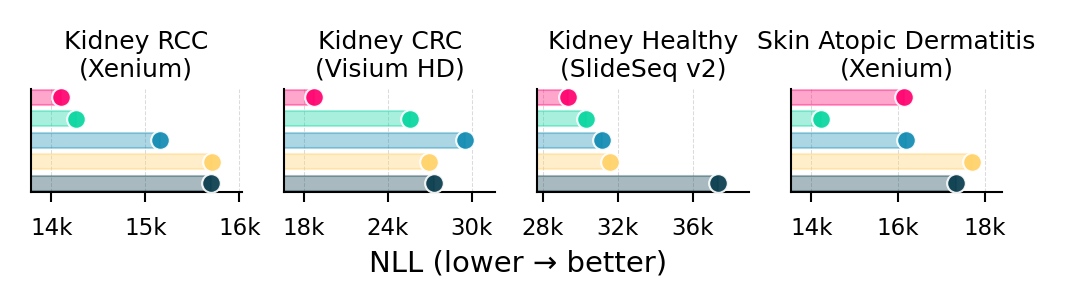

Saved nll_figure.pdf / .svg / .png


In [3]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ── Colours ─────────────────────────────────────────────────────────────
method_colors = {
    "MintFlow":     "#FF006E",  # same as other plots
    "CellCharter":  "#06D6A0",  # teal
    "NCEM":         "#118AB2",  # blue
    "STAGATE":      "#FFD166",  # amber
    "GraphST":      "#073B4C",  # dark teal
}

# Dataset display names (matching Xmic enrichment plot)
dataset_rename = {
    "Xenium old - kidney": "Kidney RCC\n(Xenium)",
    "VisiumHD - CRC": "Kidney CRC\n(Visium HD)",
    "Slide-seq - kidney": "Kidney Healthy\n(SlideSeq v2)",
    "Xenium old - beacon": "Skin Atopic Dermatitis\n(Xenium)",
}

OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/disentanglement"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load data ───────────────────────────────────────────────────────────
df_nll = pd.read_pickle(
    "/nfs/team361/aa36/OnGit/mintflow-benchmarking/Metrics/"
    "1_Disentanglement/3_Actual_Benchmarks/NonGit/ToMakeFigs/"
    "RealData/R2Benchmark/NLL_overal.pkl"
)
df_nll = df_nll[df_nll["dataset"] != "Xenium new - psoriasis"]

# Take last index per method/dataset
last = df_nll.loc[df_nll.groupby(["dataset", "method"])["idx"].idxmax()]
pivot = last.pivot(index="dataset", columns="method", values="NLL")

# Sort methods by mean NLL ascending (lowest = best on top)
sorted_methods = pivot.mean().sort_values().index.tolist()
pivot_sorted = pivot[sorted_methods]

# Explicit dataset order (matching user specification)
dataset_order = [
    "1024HVGs_1_RCC",           # Kidney RCC (Xenium)  — mapped from Xenium old - kidney
    "4_CRC_VisiumHD_Publis",    # Kidney CRC (Visium HD) — mapped from VisiumHD - CRC  
    "SlideSeq_Kidney_puck01",   # Kidney Healthy (SlideSeq v2)
    "Z_AD_10sections",          # Skin Atopic Dermatitis (Xenium) — mapped from Xenium old - beacon
]
# The pickle uses different keys — map from pickle names to our order
pickle_to_order = {
    "Xenium old - kidney": 0,
    "VisiumHD - CRC": 1,
    "Slide-seq - kidney": 2,
    "Xenium old - beacon": 3,
}
datasets = sorted(pivot_sorted.index.tolist(), key=lambda d: pickle_to_order.get(d, 99))
methods = sorted_methods
n_methods = len(methods)
n_datasets = len(datasets)

# Save processed CSV
pivot_sorted.to_csv(os.path.join(OUT_DIR, "nll_processed.csv"))
print("Saved nll_processed.csv")


# ── Helper: plot one dataset panel ──────────────────────────────────────
def plot_dataset_panel(ax, values, methods, dataset_name, show_ylabels=True):
    """Plot a single dataset panel. values is a Series indexed by method."""
    y = np.arange(len(methods))

    for i, method in enumerate(methods):
        val = values.get(method, np.nan)
        if pd.isna(val):
            ax.text(
                0.5, i, "n/a",
                va="center", ha="center",
                fontsize=5.5, fontstyle="italic", color="0.5",
                transform=ax.get_yaxis_transform(),
            )
        else:
            ax.barh(
                i, val, height=0.7,
                color=method_colors[method],
                edgecolor=method_colors[method],
                linewidth=0.5, alpha=0.35, zorder=2,
            )
            ax.scatter(
                val, i, s=20, color=method_colors[method],
                edgecolors="white", linewidths=0.5, zorder=4, alpha=0.92,
            )

    ax.set_yticks(y)
    if show_ylabels:
        ax.set_yticklabels(methods, fontweight="medium")
    else:
        ax.set_yticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-0.4, len(methods) - 0.6)
    ax.invert_yaxis()

    ax.xaxis.grid(True, linewidth=0.25, alpha=0.35, color="0.6", linestyle="--")
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)

    # Limit x-ticks: show only 3 ticks, format as "15k", "20k" etc.
    from matplotlib.ticker import MaxNLocator, FuncFormatter
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=False))
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, _: f"{x/1000:.0f}k"))

    display_name = dataset_rename.get(dataset_name, dataset_name)
    ax.set_title(display_name, fontsize=6, fontweight="medium", pad=3)


# ── Create 1×N panel figure ─────────────────────────────────────────────
panel_width = 18 * mm
row_height = 0.12
fig_height = n_methods * row_height + 0.35
fig_width = panel_width * n_datasets + 0.65  # extra for y-labels

fig, axes = plt.subplots(
    1, n_datasets,
    figsize=(fig_width, fig_height),
    sharey=True,
)

# Per-panel x-limits
for i, dataset in enumerate(datasets):
    row = pivot_sorted.loc[dataset]
    plot_dataset_panel(axes[i], row, methods, dataset, show_ylabels=(i == 0))
    valid = row.dropna()
    lo, hi = valid.min(), valid.max()
    pad = (hi - lo) * 0.2
    axes[i].set_xlim(lo - pad, hi + pad)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, bottom=0.32)

# Single shared x-axis label
fig.text(
    0.5, 0.07,
    "NLL (lower \u2192 better)",
    ha="center", va="center", fontsize=7, fontweight="medium",
)

for ext in ["pdf", "svg", "png"]:
    fig.savefig(
        os.path.join(OUT_DIR, f"nll_figure.{ext}"),
        bbox_inches="tight",
        pad_inches=0.05,
    )
plt.show()
plt.close()
print("Saved nll_figure.pdf / .svg / .png")

## Lancaster correlation

Using NLL method order: ['MintFlow', 'CellCharter', 'NCEM', 'STAGATE', 'GraphST']
Saved lancaster_processed.csv


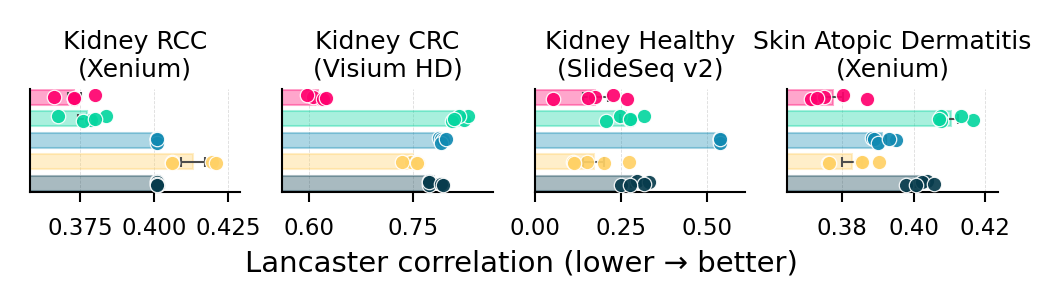

Saved lancaster_figure.pdf / .svg / .png


In [4]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import MaxNLocator

# ── Nature style settings ───────────────────────────────────────────────
mm = 1 / 25.4
mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 5.5,
    "ytick.labelsize": 6.5,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2.5,
    "ytick.major.size": 2.5,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

# ── Colours (same as NLL) ──────────────────────────────────────────────
method_colors = {
    "MintFlow":     "#FF006E",
    "CellCharter":  "#06D6A0",
    "NCEM":         "#118AB2",
    "STAGATE":      "#FFD166",
    "GraphST":      "#073B4C",
}

dataset_rename = {
    "Xenium_old___kidney": "Kidney RCC\n(Xenium)",
    "VisiumHD___CRC": "Kidney CRC\n(Visium HD)",
    "Slide_seq___kidney": "Kidney Healthy\n(SlideSeq v2)",
    "Xenium_old___beacon": "Skin Atopic Dermatitis\n(Xenium)",
}

dataset_order = {
    "Xenium_old___kidney": 0,
    "VisiumHD___CRC": 1,
    "Slide_seq___kidney": 2,
    "Xenium_old___beacon": 3,
}

OUT_DIR = (
    "/nfs/team361/sb75/mintflow-reproducibility/artifacts/"
    "benchmarking/results/disentanglement"
)
os.makedirs(OUT_DIR, exist_ok=True)

# ── Load data ───────────────────────────────────────────────────────────
df_lanc = pd.read_pickle(
    "/nfs/team361/aa36/OnGit/mintflow-benchmarking/Metrics/"
    "1_Disentanglement/3_Actual_Benchmarks/NonGit/ToMakeFigs/"
    "RealData/df_Lancaster.pkl"
)
df_lanc["value"] = pd.to_numeric(df_lanc["value"], errors="coerce")

# Pivot: rows = (dataset, attempt), columns = method
pivot = df_lanc.pivot_table(
    index=["dataset", "attempt"], columns="method", values="value"
)

# Use same method ordering as NLL plot
nll_csv_path = os.path.join(OUT_DIR, "nll_processed.csv")
if os.path.exists(nll_csv_path):
    nll_df = pd.read_csv(nll_csv_path)
    sorted_methods = [m for m in nll_df.columns if m in pivot.columns]
    print(f"Using NLL method order: {sorted_methods}")
else:
    sorted_methods = pivot.mean().sort_values(ascending=True).index.tolist()
    print("NLL CSV not found, using own sorting")
pivot_sorted = pivot[sorted_methods]

datasets = sorted(
    df_lanc["dataset"].unique().tolist(),
    key=lambda d: dataset_order.get(d, 99),
)
methods = sorted_methods
n_methods = len(methods)
n_datasets = len(datasets)

# Save processed CSV
pivot_sorted.to_csv(os.path.join(OUT_DIR, "lancaster_processed.csv"))
print("Saved lancaster_processed.csv")


# ── Helper: plot one dataset panel ──────────────────────────────────────
def plot_dataset_panel(ax, df_dataset, methods, dataset_name, show_ylabels=True):
    """Plot a single dataset panel. df_dataset has rows=runs, cols=methods."""
    y = np.arange(len(methods))
    means = df_dataset.mean()
    sems = df_dataset.sem()

    for i, method in enumerate(methods):
        if method not in df_dataset.columns or df_dataset[method].dropna().empty:
            ax.text(
                0.5, i, "n/a",
                va="center", ha="center",
                fontsize=5.5, fontstyle="italic", color="0.5",
                transform=ax.get_yaxis_transform(),
            )
        else:
            # Bar (mean)
            ax.barh(
                i, means[method], height=0.7,
                color=method_colors[method],
                edgecolor=method_colors[method],
                linewidth=0.5, alpha=0.35, zorder=2,
            )
            # Error bar (SEM)
            ax.errorbar(
                means[method], i, xerr=sems[method],
                fmt="none", ecolor="0.3", elinewidth=0.5,
                capsize=1.2, capthick=0.5, zorder=3,
            )
            # Individual run dots
            vals = df_dataset[method].dropna().values
            rng = np.random.default_rng(42 + i)
            yj = rng.uniform(-0.12, 0.12, size=len(vals))
            ax.scatter(
                vals, i + yj, s=12, color=method_colors[method],
                edgecolors="white", linewidths=0.3, zorder=4, alpha=0.92,
            )

    ax.set_yticks(y)
    if show_ylabels:
        ax.set_yticklabels(methods, fontweight="medium")
    else:
        ax.set_yticklabels([])

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-0.4, len(methods) - 0.6)
    ax.invert_yaxis()
    ax.xaxis.grid(True, linewidth=0.2, alpha=0.4, color="0.65", linestyle="--")
    ax.yaxis.grid(False)
    ax.set_axisbelow(True)
    ax.tick_params(axis="y", length=0)
    ax.xaxis.set_major_locator(MaxNLocator(nbins=3, integer=False))

    display_name = dataset_rename.get(dataset_name, dataset_name)
    ax.set_title(display_name, fontsize=6, fontweight="medium", pad=3)


# ── Create 1×N panel figure ─────────────────────────────────────────────
panel_width = 18 * mm
row_height = 0.12
fig_height = n_methods * row_height + 0.35
fig_width = panel_width * n_datasets + 0.65

fig, axes = plt.subplots(
    1, n_datasets,
    figsize=(fig_width, fig_height),
    sharey=True,
)

# Per-panel x-limits
for i, dataset in enumerate(datasets):
    df_ds = pivot_sorted.loc[dataset]
    if isinstance(df_ds, pd.Series):
        df_ds = df_ds.to_frame().T
    plot_dataset_panel(axes[i], df_ds, methods, dataset, show_ylabels=(i == 0))
    all_vals = df_ds.values.flatten()
    all_vals = all_vals[~np.isnan(all_vals)]
    if len(all_vals) > 0:
        lo, hi = all_vals.min(), all_vals.max()
        pad = (hi - lo) * 0.15
        axes[i].set_xlim(max(0, lo - pad), hi + pad)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2, bottom=0.32)

fig.text(
    0.5, 0.07,
    "Lancaster correlation (lower \u2192 better)",
    ha="center", va="center", fontsize=7, fontweight="medium",
)

for ext in ["pdf", "svg", "png"]:
    fig.savefig(
        os.path.join(OUT_DIR, f"lancaster_figure.{ext}"),
        bbox_inches="tight",
        pad_inches=0.05,
    )
plt.show()
plt.close()
print("Saved lancaster_figure.pdf / .svg / .png")